# ST1131 Introduction to Statistics and Statistical Computing
## Topic 2 (Exploratory Data Analysis)

In this topic, we will learn data analysis at the exploratory level such as summary statistics and different plots.

## Pandas

`pandas` is a package for working with tabular data, which is data organized in rows and columns, like a spreadsheet or a CSV file. It's one of the core tools in the Python data science stack, and it's what makes Python practical for the kind of data wrangling you'd otherwise reach for Excel or SQL for. Base Python is not great at handling structured data as there is no built-in "table" type. `pandas` fills that gap with two key structures, `Series` and `DataFrame`. A `Series` is a single column of data with labels (such as a column header). A `DataFrame` is a full table with many `Series` side by side. Almost everything you do in this course, such as loading a CSV, filtering rows, computing summary statistics, or even grouping data, goes through a `DataFrame`. 

Let's install and import `pandas`. We will also import our previously installed `numpy` package. I have also included two other modules from the `matplotlib` package that we will use later on in this topic, but you just need to install `matplotlib` to extract both modules.

In [1]:
#import sys #used for information about the running Python processes
#import os #operating system, used for file/folder operations and environment info
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

### Reading a dataset

We now have to load the dataset and give it a name. Previously, we had saved all our data files in a "data" folder that is a sister folder to our "src" folder. We need to use "../data/file_name". ".." means to go up one folder, so from our "src" folder, it goes up one folder to our st1131 folder first and then searches for the "data" folder. Our `pandas` package has a `read_csv` function that helps us load our `csv` dataset to Python. `csv` stands for comma-separated values, which means elements in the data are separated by commas, so Python knows that if it sees a comma, the next item should be in a new column. If its not separated by commas, then we need to indicate the separator in the function as an optional argument.

In [2]:
lung = pd.read_csv("../data/lung_cancer.csv") #the '..' means to go up one folder, while '.' means this folder
#lung = pd.read_csv("../data/lung_cancer.tsv", sep="\t") #for tab-separated values
#lung = pd.read_csv("../data/lung_cancer.txt", sep=";") #for semicolon-separated values
#lung = pd.read_csv("../data/lung_cancer.tsv", delimiter="|") #for pipe-separated values
#lung = pd.read_csv("../data/lung_cancer.tsv", sep=" ") #for single-space-separated values
#lung = pd.read_csv("../data/lung_cancer.tsv", sep=r"\s+") #for varying-space-separated values
print(type(lung))

<class 'pandas.DataFrame'>


### Checking a dataset

After loading it in, we can `print` the dataset to have a view of how the dataset look like. Notice that a `DataFrame` looks like a 2D `numpy` array, but with rows and fixed columns.

If using Jupyter Notebooks, we can actually install a viewer extension such as "Data Wrangler" and view the dataset through Jupyter. Using `print` can end up making a mess if the dataset is too big. Instead, we can use `.head()` to return just the first few rows. Other useful functions that help us get a better picture of the dataset are `.info()`, `.shape`, `.describe()`, `.columns` and `.index`.

In [3]:
#print(lung)
print(lung.head())       # first 5 rows (pandas default)
# Smoke:  1 = yes; 0 = No
# Gender: 1 = male; 0 = female
# Cancer: 1 = yes; 0 = no
print()
print(lung.info())
print()
print(lung.shape)
print()
print(lung.describe())
print()
print(lung.columns)
print()
print(lung.index)

   Cancer  Age  Gender  Smoke
0       1   68       1      1
1       1   69       0      1
2       1   55       1      1
3       1   48       1      1
4       1   73       0      1

<class 'pandas.DataFrame'>
RangeIndex: 34 entries, 0 to 33
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Cancer  34 non-null     int64
 1   Age     34 non-null     int64
 2   Gender  34 non-null     int64
 3   Smoke   34 non-null     int64
dtypes: int64(4)
memory usage: 1.2 KB
None

(34, 4)

          Cancer        Age     Gender      Smoke
count  34.000000  34.000000  34.000000  34.000000
mean    0.500000  52.323529   0.529412   0.441176
std     0.507519  13.692999   0.506640   0.503995
min     0.000000  25.000000   0.000000   0.000000
25%     0.000000  41.250000   0.000000   0.000000
50%     0.500000  51.000000   1.000000   0.000000
75%     1.000000  65.750000   1.000000   1.000000
max     1.000000  76.000000   1.000000   1.000000

Index(['Cancer

### Sorting values

You can sort your rows according to a variable of choice by using `.sort_values()`. You can also more than one variable as your choice of sorting.

In [4]:
print(lung.sort_values("Age")) #sort by age

    Cancer  Age  Gender  Smoke
15       0   25       0      0
18       0   30       0      0
32       0   31       1      0
14       0   36       1      0
19       1   37       0      0
33       0   38       1      0
12       0   39       0      0
16       0   40       0      0
8        0   40       1      1
17       0   45       0      0
31       0   46       0      1
29       0   47       0      0
3        1   48       1      1
26       1   48       1      0
22       1   49       1      0
10       1   49       0      1
28       1   49       1      1
9        0   53       0      1
11       0   53       0      0
27       1   54       1      1
21       1   55       1      1
2        1   55       1      1
23       0   58       1      0
7        1   61       0      0
25       1   65       1      1
6        1   66       1      0
20       1   67       1      0
0        1   68       1      1
30       0   68       0      1
1        1   69       0      1
24       0   70       1      0
13      

In [5]:
print(lung.sort_values(["Age", "Gender"])) #sort by age, then by gender

    Cancer  Age  Gender  Smoke
15       0   25       0      0
18       0   30       0      0
32       0   31       1      0
14       0   36       1      0
19       1   37       0      0
33       0   38       1      0
12       0   39       0      0
16       0   40       0      0
8        0   40       1      1
17       0   45       0      0
31       0   46       0      1
29       0   47       0      0
3        1   48       1      1
26       1   48       1      0
10       1   49       0      1
22       1   49       1      0
28       1   49       1      1
9        0   53       0      1
11       0   53       0      0
27       1   54       1      1
2        1   55       1      1
21       1   55       1      1
23       0   58       1      0
7        1   61       0      0
25       1   65       1      1
6        1   66       1      0
20       1   67       1      0
30       0   68       0      1
0        1   68       1      1
1        1   69       0      1
24       0   70       1      0
13      

In [6]:
print(lung.sort_values(["Gender", "Age"], ascending=[True, False])) #sort by gender, then by age

    Cancer  Age  Gender  Smoke
5        1   76       0      1
4        1   73       0      1
1        1   69       0      1
30       0   68       0      1
7        1   61       0      0
9        0   53       0      1
11       0   53       0      0
10       1   49       0      1
29       0   47       0      0
31       0   46       0      1
17       0   45       0      0
16       0   40       0      0
12       0   39       0      0
19       1   37       0      0
18       0   30       0      0
15       0   25       0      0
13       0   71       1      0
24       0   70       1      0
0        1   68       1      1
20       1   67       1      0
6        1   66       1      0
25       1   65       1      1
23       0   58       1      0
2        1   55       1      1
21       1   55       1      1
27       1   54       1      1
22       1   49       1      0
28       1   49       1      1
3        1   48       1      1
26       1   48       1      0
8        0   40       1      1
33      

### Subsetting columns

`lung["Gender"]` gives us the entire "Gender" variable from our lung dataset, and `len(lung["Gender"])` gives us the number of items in this variable. You can include more than one column when subsetting.

In [7]:
print(lung["Gender"])
#print()
#print(lung[["Gender", "Age"]])
print()
len(lung["Gender"])

0     1
1     0
2     1
3     1
4     0
5     0
6     1
7     0
8     1
9     0
10    0
11    0
12    0
13    1
14    1
15    0
16    0
17    0
18    0
19    0
20    1
21    1
22    1
23    1
24    1
25    1
26    1
27    1
28    1
29    0
30    0
31    0
32    1
33    1
Name: Gender, dtype: int64



34

### Subsetting rows

We may want to subset rows that match a certain condition. One way is to use `True` or `False` as indexes. Some useful symbols are `>` (`>=`) for greater than (or equal), `<` (`<=`) for less than (or equal), `==` for equals to, `!=` for not equals to, `&` for AND, `|` for OR. If we want to, it might even be more useful to create a new `DataFrame` entirely for the subsetted data.

In [8]:
print(lung[lung["Age"]>70]) #above 70

    Cancer  Age  Gender  Smoke
4        1   73       0      1
5        1   76       0      1
13       0   71       1      0


In [9]:
print(lung[(lung["Age"]>70) | (lung["Gender"]==0)]) #either above 70 or female

    Cancer  Age  Gender  Smoke
1        1   69       0      1
4        1   73       0      1
5        1   76       0      1
7        1   61       0      0
9        0   53       0      1
10       1   49       0      1
11       0   53       0      0
12       0   39       0      0
13       0   71       1      0
15       0   25       0      0
16       0   40       0      0
17       0   45       0      0
18       0   30       0      0
19       1   37       0      0
29       0   47       0      0
30       0   68       0      1
31       0   46       0      1


In [10]:
lungOldFemale=lung[(lung["Age"]>70) & (lung["Gender"]==0)] #above 70 and female
print(lungOldFemale) 

   Cancer  Age  Gender  Smoke
4       1   73       0      1
5       1   76       0      1


If we want a few exact criteria from Age, it can get tedious to write all the different conditions. Instead we can list out what numbers we want and then use `.isin()` as a single condition.

In [11]:
age_wanted=[46,49,66]
print(lung[lung["Age"].isin(age_wanted)])

    Cancer  Age  Gender  Smoke
6        1   66       1      0
10       1   49       0      1
22       1   49       1      0
28       1   49       1      1
31       0   46       0      1


### Adding columns with permutations from other columns

We can create new columns easily with operations from one or more columns. In this example, I want to create a column that just tells me if its a male with cancer, and a column that shows me age in terms of months. Later, we will cover an example that uses a `dictionary` and `map()`.

In [12]:
lung["MaleCancer"]=lung["Gender"]*lung["Cancer"]
lung["AgeMonth"]=12*lung["Age"]
print(lung)

    Cancer  Age  Gender  Smoke  MaleCancer  AgeMonth
0        1   68       1      1           1       816
1        1   69       0      1           0       828
2        1   55       1      1           1       660
3        1   48       1      1           1       576
4        1   73       0      1           0       876
5        1   76       0      1           0       912
6        1   66       1      0           1       792
7        1   61       0      0           0       732
8        0   40       1      1           0       480
9        0   53       0      1           0       636
10       1   49       0      1           0       588
11       0   53       0      0           0       636
12       0   39       0      0           0       468
13       0   71       1      0           0       852
14       0   36       1      0           0       432
15       0   25       0      0           0       300
16       0   40       0      0           0       480
17       0   45       0      0           0    

### Functions

Some functions are done differently than from `numpy`. Examples are `mean` and `median`.

In [13]:
print(lung["Age"].mean())
print(lung["Age"].median())
print(lung["Age"].min())
print(lung["Age"].max())
print(lung["Age"].var()) #sample variance
print(lung["Age"].std()) #sample standard deviation


52.3235294117647
51.0
25
76
187.4982174688057
13.69299884863815


There are many other functions that `pandas` provide. We will slowly learn them over time.

### Frequency tables

We can use `.value_counts()` in different ways to help us count information from our dataset. We can even include optional arguments to help us convert it to proportion, sort for us, or even include missing values.

In [14]:
print(lung["Gender"].value_counts())           # counts

Gender
1    18
0    16
Name: count, dtype: int64


In [15]:
print(lung["Gender"].value_counts(normalize=True))          # proportions

Gender
1    0.529412
0    0.470588
Name: proportion, dtype: float64


In [16]:
print(lung["Gender"].value_counts(normalize=True, ascending=True)* 100)          # percentages

Gender
0    47.058824
1    52.941176
Name: proportion, dtype: float64


To make things more readable, we may want to change from 0 and 1 to Female and Male. There are a few ways we can do that. One new way is to use a dictionary and `map()` function. We will create a new variable `"gender"` instead of reusing `"Gender"`.

In [17]:
lung["gender"] = lung["Gender"].map({0: "Female", 1: "Male"})
print(lung["gender"].value_counts())
print()
print(lung["gender"].value_counts(normalize=True))
print()
print(lung["gender"].value_counts(normalize=True, ascending=True) * 100)

gender
Male      18
Female    16
Name: count, dtype: int64

gender
Male      0.529412
Female    0.470588
Name: proportion, dtype: float64

gender
Female    47.058824
Male      52.941176
Name: proportion, dtype: float64


Another way is using the `apply()` function instead.

In [18]:
lung["gender"] = lung["Gender"].apply(lambda x: "Female" if x == 0 else "Male")
print(lung["gender"].value_counts())
print()
print(lung["gender"].value_counts(normalize=True))
print()
print(lung["gender"].value_counts(normalize=True, ascending=True) * 100)

gender
Male      18
Female    16
Name: count, dtype: int64

gender
Male      0.529412
Female    0.470588
Name: proportion, dtype: float64

gender
Female    47.058824
Male      52.941176
Name: proportion, dtype: float64


Sometimes, we may want to let Python know that the variable is a categorical variable and should be treated like one. The reason is because some categorical variables appear as numbers so Python may not know. It also allows you to control the order of categories, which is important for plots and tables. In this first example, we will not be setting an order. It is also time to highlight that `value_counts()` naturally sorts things from highest to lowest count.

In [19]:
lung["gender"] = pd.Categorical(lung["Gender"].map({0: "Female", 1: "Male"}), categories=["Female", "Male"])
 
print(lung["gender"].value_counts())
print()
print(lung["gender"].value_counts(normalize=True))
print()
print(lung["gender"].value_counts(normalize=True, ascending=True) * 100)

gender
Male      18
Female    16
Name: count, dtype: int64

gender
Male      0.529412
Female    0.470588
Name: proportion, dtype: float64

gender
Female    47.058824
Male      52.941176
Name: proportion, dtype: float64


We can intentionally define an order for Python to follow. In this case, we will make it such that Female is ordered before Male. We also need to inform Python to stop sorting our tables by highest to lowest count, so that it follows our order instead.

In [20]:
lung["gender"] = pd.Categorical(lung["Gender"].map({0: "Female", 1: "Male"}), categories=["Female", "Male"], ordered=True)

print(lung["gender"].value_counts(sort=False))
print()
print(lung["gender"].value_counts(normalize=True, sort=False))
print()
print(lung["gender"].value_counts(normalize=True, sort=False) * 100)

gender
Female    16
Male      18
Name: count, dtype: int64

gender
Female    0.470588
Male      0.529412
Name: proportion, dtype: float64

gender
Female    47.058824
Male      52.941176
Name: proportion, dtype: float64


Try doing the frequency tables for `cancer` (categorised into No and Yes) and `age` (categorised into 25-45, 46-65 and more than 65).

In [21]:
lung["cancer"] = pd.Categorical(lung["Cancer"].map({0: "No", 1: "Yes"}), categories=["No", "Yes"], ordered=True)

print(lung["cancer"].value_counts(sort=False))
print()
print(lung["cancer"].value_counts(normalize=True, sort=False))
print()
print(lung["cancer"].value_counts(normalize=True, sort=False) * 100)

cancer
No     17
Yes    17
Name: count, dtype: int64

cancer
No     0.5
Yes    0.5
Name: proportion, dtype: float64

cancer
No     50.0
Yes    50.0
Name: proportion, dtype: float64


For `age`, we cannot use the `map()` function which works best for exact value replacements. Instead, we either use `apply()` which requires a more complicated function, or `pd.cut()` which is the recommended way for numerical binning. By default, `pd.cut()` creates bins that are left-exclusive, right-inclusive. Therefore, `[25, 45, 65, float("inf")]` creates intervals "(25-45], (45-65] and (65+)". If we want to ensure that 25 is included in the 25-45 group, we add `include_lowest=True`. 

`pd.cut()` usually returns a categorical by default, but it is good practice to check using `dtype`. If it shows category, it is already categorical. If not, you can explicitly convert it according to our previous examples.

In [22]:
lung["age"] = pd.cut(lung["Age"], bins=[25, 45, 65, float("inf")], labels=["25-45", "46-65", "more than 65"], include_lowest=True)
print(lung["age"].dtype)
print()

print(lung["age"].value_counts(sort=False))
print()
print(lung["age"].value_counts(normalize=True, sort=False))
print()
print(lung["age"].value_counts(normalize=True, sort=False) * 100)

category

age
25-45           10
46-65           15
more than 65     9
Name: count, dtype: int64

age
25-45           0.294118
46-65           0.441176
more than 65    0.264706
Name: proportion, dtype: float64

age
25-45           29.411765
46-65           44.117647
more than 65    26.470588
Name: proportion, dtype: float64


### Bar plots

We first have to create the appropriate information for the bar plot, which is the count of each category. Then we use `plt.figure()` to create a new blank canvas for our plot. Without it, `matplotlib` might draw your new plot on top of the previous one. This code gives us the most basic bar plot with no further customisations. This function only works for `pandas` `Series`/`DataFrame`.

gender
Female    16
Male      18
Name: count, dtype: int64


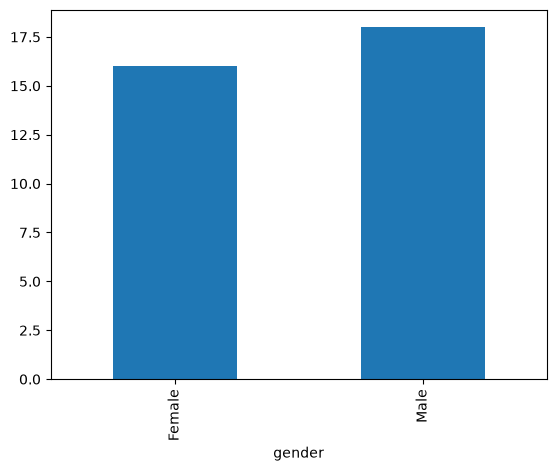

In [23]:
counts = lung["gender"].value_counts(sort=False)
print(counts)

plt.figure()
counts.plot(kind="bar")
plt.show() #shows the plot, this is not needed if running on VS Code with Jupyter cells

We should try to add some customisations to our bar plot for better visualisation.

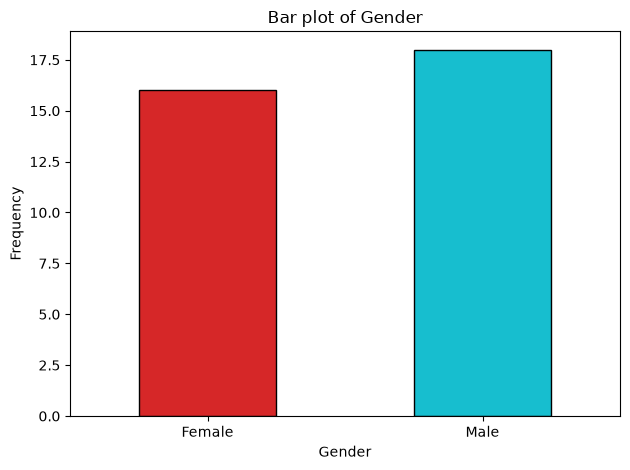

In [24]:
plt.figure()
counts.plot(kind="bar", color=["tab:red", "tab:cyan"], edgecolor="black")
plt.ylabel("Frequency") #label for y-axis
plt.xlabel("Gender") #label for x-axis
plt.title("Bar plot of Gender") #label for title
plt.xticks(rotation=0) #rotation angle of categories in x-axis
plt.tight_layout() #automatically adjusts the plot so that everything fits neatly without overlapping
plt.show() #shows the plot, this is not needed if running on VS Code with Jupyter cells

Try doing the bar plot for age (categorised into 25-45, 46-65 and more than 65). Note that the `"tab:"` colours only has 10 options `(tab:blue, tab:orange, tab:green, tab:red, tab:purple, tab:brown, tab:pink, tab:gray, tab:olive, tab:cyan)`. There are other colour options outside of this 10, such as `limegreen`. Do note that `plt.bar()` also works as an alternative for bar plots that are using `lists`, `arrays`, or `pandas` `Series`/`DataFrames`.

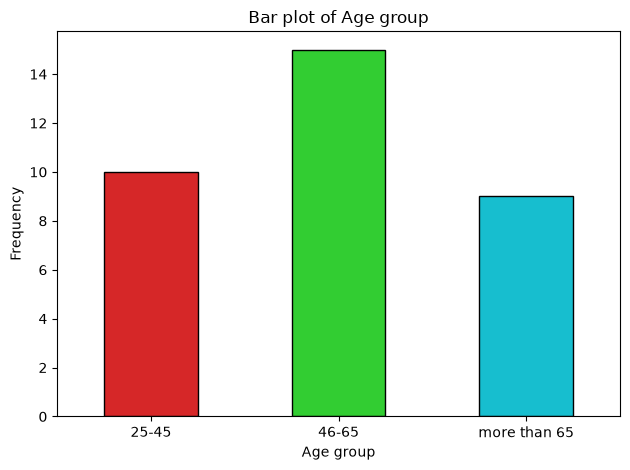

In [25]:
counts = lung["age"].value_counts(sort=False)
plt.figure()
counts.plot(kind="bar", color=["tab:red", "limegreen", "tab:cyan"], edgecolor="black")
#plt.bar(counts.index, counts.values, color=["tab:red", "limegreen", "tab:cyan"], edgecolor="black")
plt.ylabel("Frequency")
plt.xlabel("Age group")
plt.title("Bar plot of Age group")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Here is another example where we directly create the categories and their respective counts without a dataset. Since this manual input of data is not a `pandas` `Series`/`DataFrame`, we use `plt.bar()` instead.

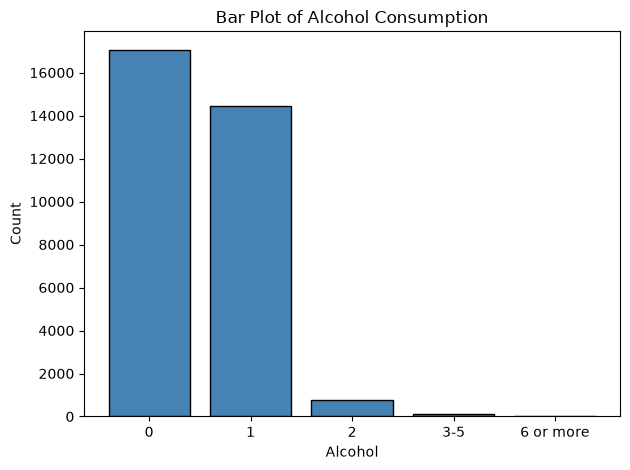

In [26]:
count = [17066, 14464, 788, 126, 37]
alcohol = ["0", "1", "2", "3-5", "6 or more"]
 
plt.figure()
bars = plt.bar(alcohol, count, color="steelblue", edgecolor="black")
plt.xlabel("Alcohol")
plt.ylabel("Count")
plt.title("Bar Plot of Alcohol Consumption")
plt.tight_layout()
plt.show()

We can also choose to include the count of each category above their respective bars.

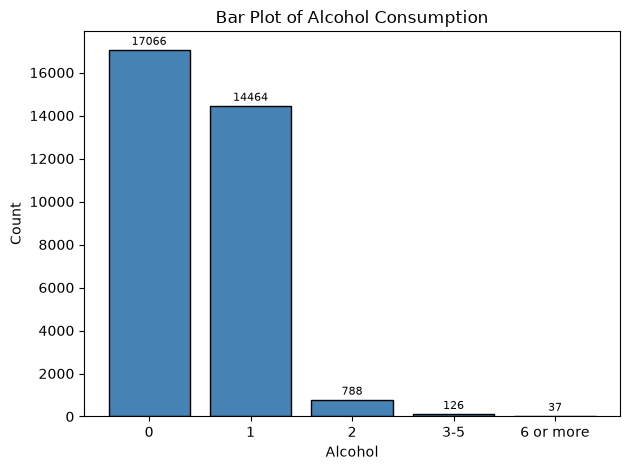

In [27]:
plt.figure()
bars = plt.bar(alcohol, count, color="steelblue", edgecolor="black")
for bar, val in zip(bars, count):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 100,
             str(val), ha="center", va="bottom", fontsize=8)
plt.xlabel("Alcohol")
plt.ylabel("Count")
plt.title("Bar Plot of Alcohol Consumption")
plt.tight_layout()
plt.show()

We can change our bar plot to show proportion (or percentages by multiplying by 100) instead of count by feeding proportion values instead of count values to the bar plot.

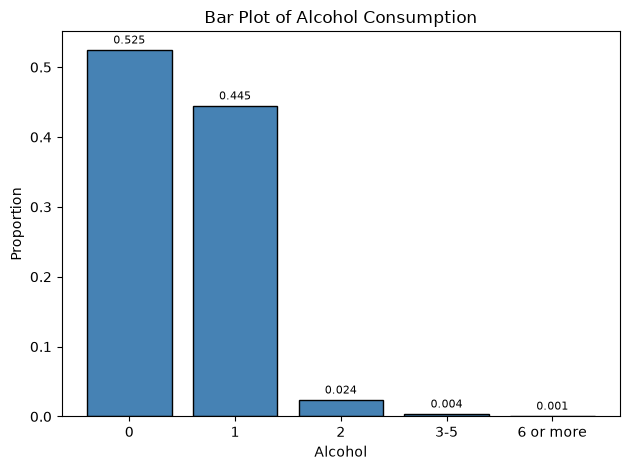

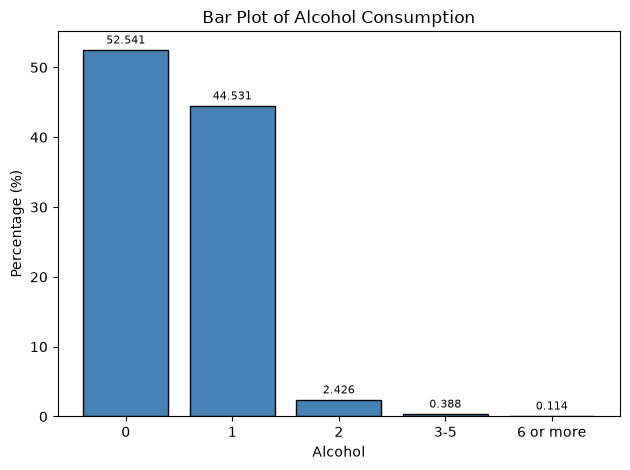

In [28]:
count = [17066, 14464, 788, 126, 37]
alcohol = ["0", "1", "2", "3-5", "6 or more"]
total = sum(count)
proportion = [round(c/total,3) for c in count] #round(,3) helps round off the values to 3dp

plt.figure()
bars = plt.bar(alcohol, proportion, color="steelblue", edgecolor="black")
for bar, val in zip(bars, proportion):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
             str(val), ha="center", va="bottom", fontsize=8)
plt.xlabel("Alcohol")
plt.ylabel("Proportion")
plt.title("Bar Plot of Alcohol Consumption")
plt.tight_layout()
plt.show()

percentage = [round(c/total*100,3) for c in count]
plt.figure()
bars = plt.bar(alcohol, percentage, color="steelblue", edgecolor="black")
for bar, val in zip(bars, percentage):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
             str(val), ha="center", va="bottom", fontsize=8)
plt.xlabel("Alcohol")
plt.ylabel("Percentage (%)")
plt.title("Bar Plot of Alcohol Consumption")
plt.tight_layout()
plt.show()

### Pie Charts

This is very similar to bar plots, just that we call the `pie` function instead. The `autopct` parameter automatically displays the percentage on each slice. `"%1.1f"` is to display 1 decimal place, we can change to `"%1.0f"` for no decimal place or `"%1.2f"` for 2 decimal places. The `"%%"` at the end displays the percentage symbol.

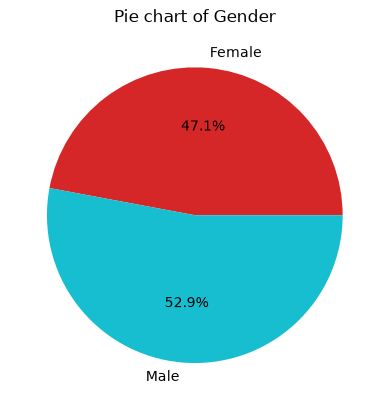

In [29]:
counts = lung["gender"].value_counts(sort=False)
 
plt.figure()
plt.pie(counts, labels=counts.index,
        colors=["tab:red", "tab:cyan"], autopct="%1.1f%%")
plt.title("Pie chart of Gender")
plt.show()

### Histograms

Using a manually created set of BMI data, we can easily make a histogram using `plt.hist()`. We can set the bins of the histogram by writing it out as `bins=[10, 15, 20, 25, 30, 35]` or by using `bins=np.arange(10, 36, 5)` which creates bins from 10 to 36 (exclusive of 36 which is why we have to be higher than 35 if we want 35 to be included) with a step of 5. 

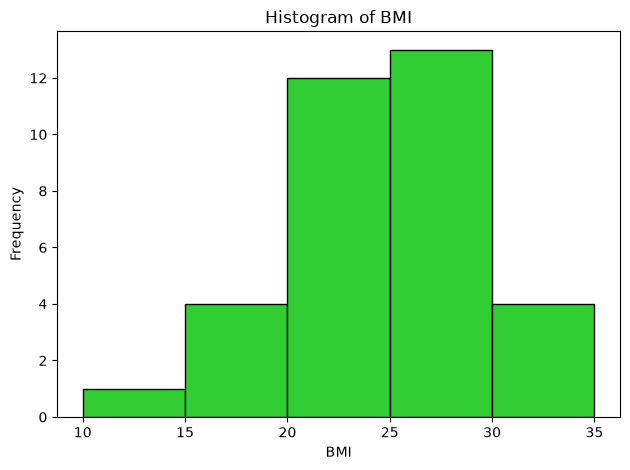

In [30]:
BMI = [29.5,28.6,24.7,28.8,23.7,23.3,28.8,26.7,23.6,27.1,24.5,20.7,28,24.7,16.3,26,14,
25.8,17.5,30.7,17.5,30.6,29.7,24.5,35,21.9,20.9,24.3,27.3,26.5, 22,16.3, 30.1, 27.2]

plt.figure()
plt.hist(BMI, bins=np.arange(10, 36, 5), color="limegreen", edgecolor="black")
plt.xlabel("BMI")
plt.ylabel("Frequency")
plt.title("Histogram of BMI")
plt.tight_layout()
plt.show()

We can change from frequency to probability by adding `density=True`.

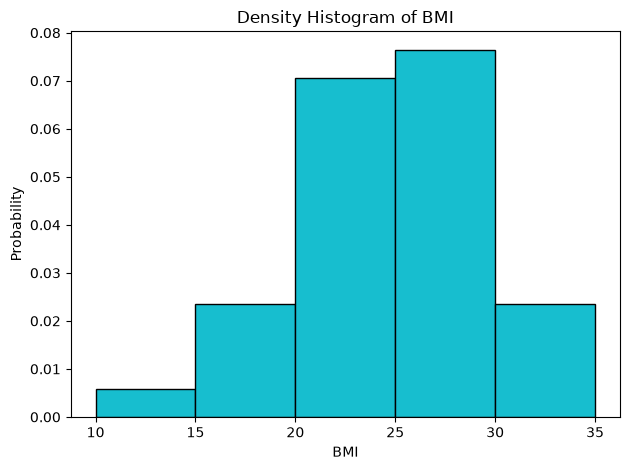

In [31]:
plt.figure()
plt.hist(BMI, bins=np.arange(10, 36, 5), density=True, color="tab:cyan", edgecolor="black")
plt.xlabel("BMI")
plt.ylabel("Probability")
plt.title("Density Histogram of BMI")
plt.tight_layout()
plt.show()

Here are some different shapes of histograms that are generated from simulated data. You do not need to learn the Python code for this, it is meant to generate some simulated histograms that you see in your lecture videos.

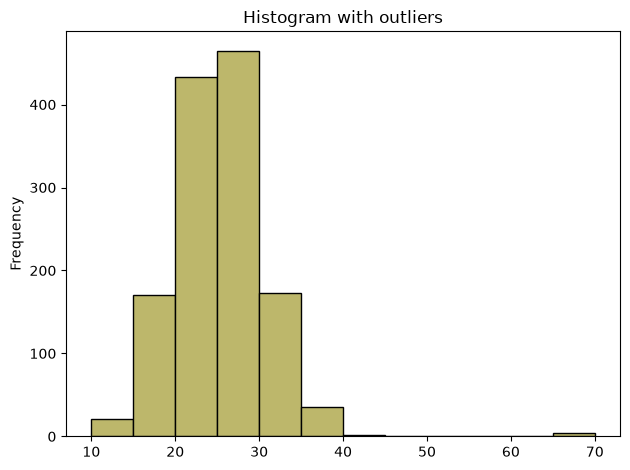

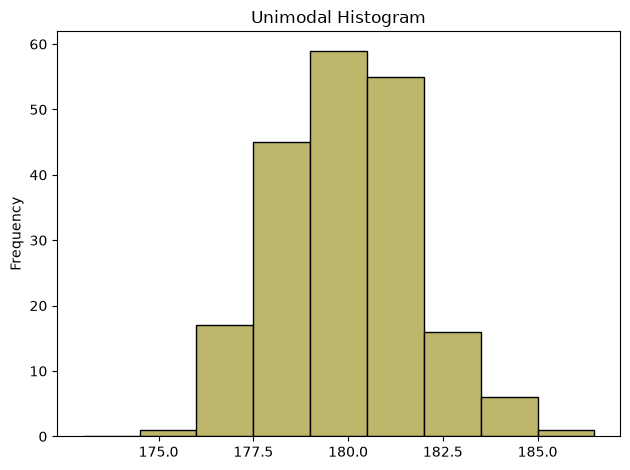

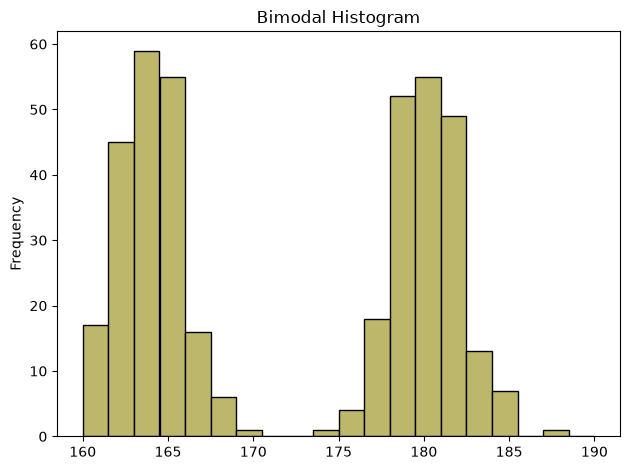

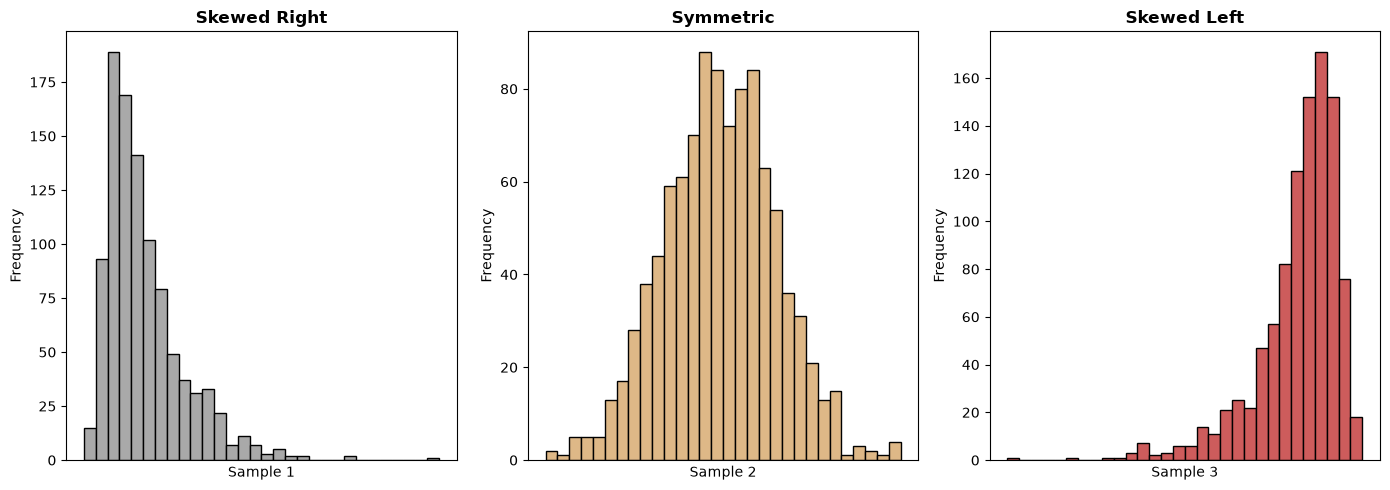

In [32]:
np.random.seed(42)
main_data = np.random.normal(loc=25, scale=5, size=1300)
main_data = main_data[(main_data >= 10) & (main_data <= 55)]  # remove extremes
outliers = np.random.uniform(65, 70, size=4)
simulated_mark = np.concatenate([main_data, outliers])
plt.figure()
plt.hist(simulated_mark, bins=np.arange(10, 71, 5), color="darkkhaki", edgecolor="black")
plt.ylabel("Frequency")
plt.title("Histogram with outliers")
plt.xticks(np.arange(10, 71, 10))
plt.tight_layout()
plt.show()

np.random.seed(42)
simulated_y = np.random.normal(loc=180, scale=2, size=200)
plt.figure()
plt.hist(simulated_y, bins=np.arange(173, 188, 1.5), color="darkkhaki", edgecolor="black")
plt.ylabel("Frequency")
plt.title("Unimodal Histogram")
plt.xticks(np.arange(175, 187, 2.5))  # x-axis ticks at 175, 177.5, 180, 182.5, 185
plt.tight_layout()
plt.show()

np.random.seed(42)
group1 = np.random.normal(loc=164, scale=2, size=200)
group2 = np.random.normal(loc=180, scale=2, size=200)
simulated_x = np.concatenate([group1, group2])
plt.figure()
plt.hist(simulated_x, bins=np.arange(160, 191, 1.5), color="darkkhaki", edgecolor="black")
plt.ylabel("Frequency")
plt.title("Bimodal Histogram")
plt.xticks(np.arange(160, 191, 5))  # x-axis ticks at 160, 165, 170, 175, 180, 185, 190
plt.tight_layout()
plt.show()

np.random.seed(42)
sample1 = np.random.exponential(scale=2, size=1000) + np.random.normal(loc=0, scale=0.5, size=1000)
sample2 = np.random.normal(loc=0, scale=1, size=1000)
sample3 = -np.random.exponential(scale=2, size=1000) + np.random.normal(loc=0, scale=0.5, size=1000)
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
axes[0].hist(sample1, bins=30, color="darkgray", edgecolor="black")
axes[0].set_title("Skewed Right", fontweight="bold")
axes[0].set_xlabel("Sample 1")
axes[0].set_ylabel("Frequency")
axes[0].set_xticks([])
axes[1].hist(sample2, bins=30, color="burlywood", edgecolor="black")
axes[1].set_title("Symmetric", fontweight="bold")
axes[1].set_xlabel("Sample 2")
axes[1].set_ylabel("Frequency")
axes[1].set_xticks([])
axes[2].hist(sample3, bins=30, color="indianred", edgecolor="black")
axes[2].set_title("Skewed Left", fontweight="bold")
axes[2].set_xlabel("Sample 3")
axes[2].set_ylabel("Frequency")
axes[2].set_xticks([])
plt.tight_layout()
plt.show()

### Numerical Summaries

Here is a list of functions that give us different summary statistics. You can round off whichever values by using `round()`.

In [33]:
data = pd.read_csv("../data/midterm_marks.csv")
mark = data.iloc[:, 1].rename("mark")   # all rows in second column (0-indexed), note the difference between iloc and loc
 
print("Combination of count, mean, std dev and 5-number summary:")
print(mark.describe())
print()
print("Length:", len(mark))
print()
print("Min:", mark.min())
print()
print("Max:", mark.max())
print()
print("Mean:", mark.mean())
print()
print("Median:", mark.median())
print()
print("30th percentile:", mark.quantile(0.30))
print()
print("Q1:", mark.quantile(0.25))
print()
print("Q3:", mark.quantile(0.75))
print()
print("IQR:", mark.quantile(0.75) - mark.quantile(0.25))
print()
print("Range:", [mark.min(), mark.max()])
print("Range:", [float(mark.min()), float(mark.max())])
print()
print("Variance:", mark.var())
print()
print("Std Dev:", mark.std())

Combination of count, mean, std dev and 5-number summary:
count    98.000000
mean     18.051020
std       8.411605
min       0.500000
25%      12.625000
50%      18.750000
75%      24.375000
max      60.000000
Name: mark, dtype: float64

Length: 98

Min: 0.5

Max: 60.0

Mean: 18.051020408163264

Median: 18.75

30th percentile: 13.5

Q1: 12.625

Q3: 24.375

IQR: 11.75

Range: [np.float64(0.5), np.float64(60.0)]
Range: [0.5, 60.0]

Variance: 70.75510204081633

Std Dev: 8.411605200008873


More examples of histograms.

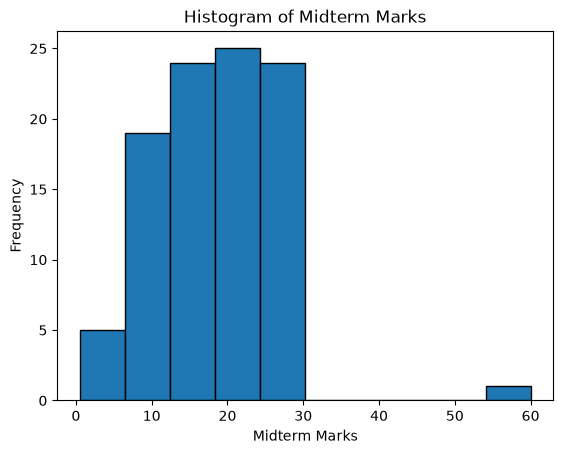

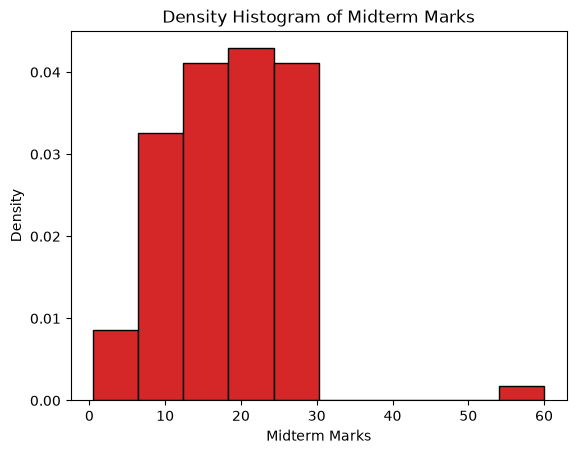

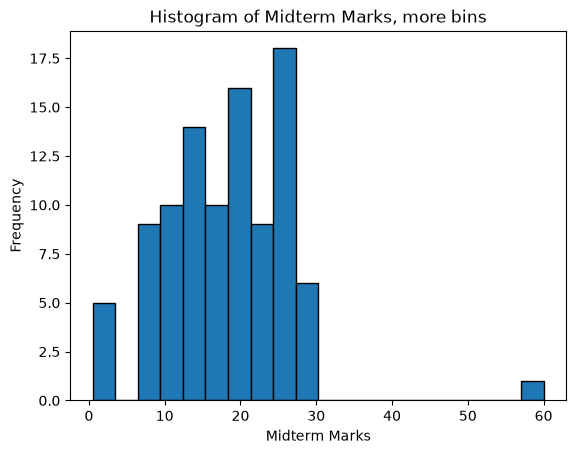

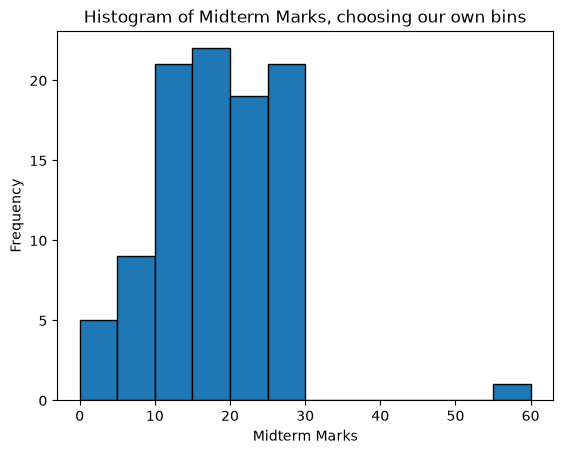

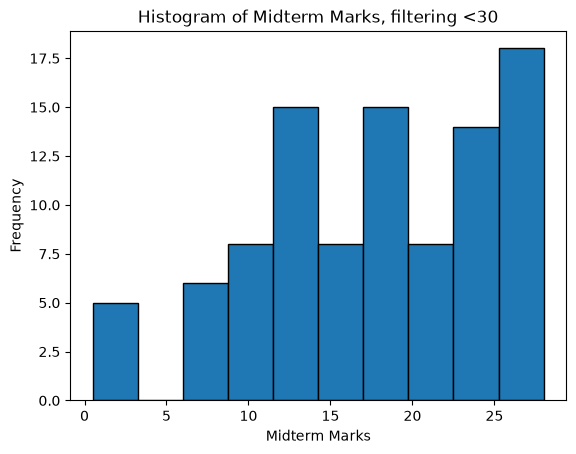

In [34]:
plt.figure()
plt.hist(mark, edgecolor="black")
plt.xlabel("Midterm Marks")
plt.ylabel("Frequency")
plt.title("Histogram of Midterm Marks")
plt.show()
 
plt.figure()
plt.hist(mark, density=True, color="tab:red", edgecolor="black")
plt.xlabel("Midterm Marks")
plt.ylabel("Density")
plt.title("Density Histogram of Midterm Marks")
plt.show()

plt.figure()
plt.hist(mark, bins=20, edgecolor="black")
plt.xlabel("Midterm Marks")
plt.ylabel("Frequency")
plt.title("Histogram of Midterm Marks, more bins")
plt.show()

plt.figure()
plt.hist(mark, bins=np.arange(0, 65, 5), edgecolor="black")
plt.xlabel("Midterm Marks")
plt.ylabel("Frequency")
plt.title("Histogram of Midterm Marks, choosing our own bins")
plt.show()
 
plt.figure()
plt.hist(mark[mark < 30], edgecolor="black")
plt.xlabel("Midterm Marks")
plt.ylabel("Frequency")
plt.title("Histogram of Midterm Marks, filtering <30")
plt.show()

### Boxplots

We can manually calculate the outliers that will appear in a boxplot by doing the mathematical calculations.

In [35]:
q1, q3 = mark.quantile(0.25), mark.quantile(0.75)
iqr = q3 - q1
lower_fence = q1 - 1.5 * iqr
upper_fence = q3 + 1.5 * iqr
outliers = mark[(mark < lower_fence) | (mark > upper_fence)]
print("Outliers:", outliers.tolist())

Outliers: [60.0]


We can plot the boxplot using the `boxplot` function.

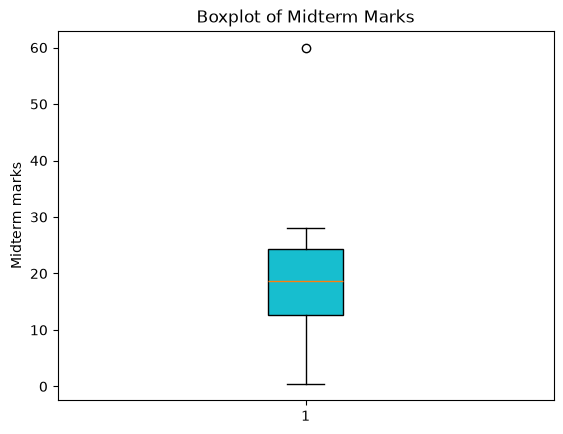

In [40]:
plt.figure()
#bp = plt.boxplot(mark, vert=True) # without colour
bp = plt.boxplot(mark, orientation='vertical', patch_artist=True, boxprops=dict(facecolor="tab:cyan"))
plt.ylabel("Midterm marks")
plt.title("Boxplot of Midterm Marks")
plt.show()

Outliers can also be retrieved from the boxplot directly using `"fliers"`. You can also extract the index of the outlier so that you know which row it belongs to. However, using the function `np.isin()` may miss outliers if the same value appears multiple times in the data.

In [ ]:
print("Using fliers method")
outliers = bp["fliers"][0].get_data()[1]
print("Outliers:", outliers)
indices = np.where(np.isin(mark, outliers))[0]
print("Indices of outliers:", indices)
print("Values at those indices:", mark.iloc[indices].values)
print()

print("Replace np.isin() with a condition instead")
condition = (mark < lower_fence) | (mark > upper_fence)
indices = np.where(condition)[0]
print("Indices of outliers:", indices)
print("Values at those indices:", mark.iloc[indices].values)
print()

print("Alternatively")
condition = (mark < lower_fence) | (mark > upper_fence)
print("Indices of outliers:", mark[condition].index.tolist())
print("Values of outliers:", mark[condition].tolist())

Using fliers method
Outliers: [60.]
Indices of outliers: [33]
Values at those indices: [60.]

Replace np.isin() with a condition instead
Indices of outliers: [33]
Values at those indices: [60.]

Alternatively
Indices of outliers: [33]
Values of outliers: [60.0]


### 2 x 2 Contingency Tables

We will now look into 2 x 2 Contingency Tables. We will use the breast cancer dataset for this.

In [ ]:
bc = pd.read_csv("../data/breast_cancer.csv")
# bbd: cancer status, 0 = no; 1 = yes
# pmh: post-menopausal hormone usage: 2 = no; 3 = yes
# alcohol: amount of alcohol consumed
# hgt: height of participant
# agemenop: age of participant at menopause
# bmi: body mass index of participant

print()
print(bc.head())
print()
print(pd.crosstab(bc["bbd"], bc["pmh"]))


   Unnamed: 0      Id  agemenop  bbd  pmh  bmi  alcohol  hgt
0           1  100013        45    1    2   26        1   65
1           2  100015        39    1    2   26        8   61
2           3  100016        36    1    3   28        1   64
3           4  100017        53    1    2   29        0   62
4           5  100018        53    0    2   32       12   62

pmh    2    3
bbd          
0    682  121
1    318   79


The 2 x 2 table is shown above but the information is not clear. To better view the information in our contingency table, it is best to rename the categories from 0s and 1s to something more appropriate. Let's rename the variables and categories for `"bbd"` and `"pmh"` into something that is clearer.

In [ ]:
cancer = bc["bbd"].map({0: "Absent", 1: "Present"}).rename("cancer")
pmh_use = bc["pmh"].map({2: "No", 3: "Yes"}).rename("pmh_use")

print("2 x 2 Contingency Table")
tab = pd.crosstab(cancer, pmh_use)
print(tab)
print()
tab2 = pd.crosstab(pmh_use, cancer)
print(tab2)


2 x 2 Contingency Table
pmh_use   No  Yes
cancer           
Absent   682  121
Present  318   79

cancer   Absent  Present
pmh_use                 
No          682      318
Yes         121       79


We can also change the information inside the table to percentages. We can either choose overall, row or column percentages. `.div()` is a method for dividing a `DataFrame`/`Series` by something. Here we divided either by the row total or the column total to get our needed percentages. `.sum(axis=1)` sums across each row, then `.div(..., axis=0)` divides each row of counts by the correspending value given. Likewise, `.sum(axis=0)` sums across each column, then `.div(..., axis=1)` divides each column of counts by the correspending value given.

In [ ]:
tab = pd.crosstab(cancer, pmh_use)

print("2 x 2 Contigency Table by Overall Percentage")
proptab = tab / tab.values.sum() * 100
print(proptab)

print()
print("2 x 2 Contigency Table by Row Percentage")
# Conditional probabilities: condition on cancer (rows sum to 100%)
proptab_row = tab.div(tab.sum(axis=1), axis=0) * 100
print(proptab_row)
 
print()
print("2 x 2 Contigency Table by Column Percentage")
# Conditional probabilities: condition on pmh_use (columns sum to 100%)
proptab_col = tab.div(tab.sum(axis=0), axis=1) * 100
print(proptab_col)

2 x 2 Contigency Table by Overall Percentage
pmh_use         No        Yes
cancer                       
Absent   56.833333  10.083333
Present  26.500000   6.583333

2 x 2 Contigency Table by Row Percentage
pmh_use         No        Yes
cancer                       
Absent   84.931507  15.068493
Present  80.100756  19.899244

2 x 2 Contigency Table by Column Percentage
pmh_use    No   Yes
cancer             
Absent   68.2  60.5
Present  31.8  39.5


The `.crosstab()` function has an optional argument `normalize` that can do the above quicker.

In [ ]:
print("2 x 2 Contigency Table by Overall Percentage")
proptab = pd.crosstab(cancer, pmh_use, normalize=True) * 100
print(proptab)

print()
print("2 x 2 Contigency Table by Row Percentage")
# Conditional probabilities: condition on cancer (rows sum to 100%)
proptab_row = pd.crosstab(cancer, pmh_use, normalize="index") * 100
print(proptab_row)
 
print()
print("2 x 2 Contigency Table by Column Percentage")
# Conditional probabilities: condition on pmh_use (columns sum to 100%)
proptab_col = pd.crosstab(cancer, pmh_use, normalize="columns") * 100
print(proptab_col)

2 x 2 Contigency Table by Overall Percentage
pmh_use         No        Yes
cancer                       
Absent   56.833333  10.083333
Present  26.500000   6.583333

2 x 2 Contigency Table by Row Percentage
pmh_use         No        Yes
cancer                       
Absent   84.931507  15.068493
Present  80.100756  19.899244

2 x 2 Contigency Table by Column Percentage
pmh_use    No   Yes
cancer             
Absent   68.2  60.5
Present  31.8  39.5


### Clustered Bar Plots

To create a clustered bar plot, you first need to decide which variable you want on your $x$-axis. That variable needs to be set as your rows in the 2 x 2 table, and then conditioned on (form row percentages). Let's say we want `"pmh_use"` on our $x$-axis.

cancer   Absent  Present
pmh_use                 
No         68.2     31.8
Yes        60.5     39.5


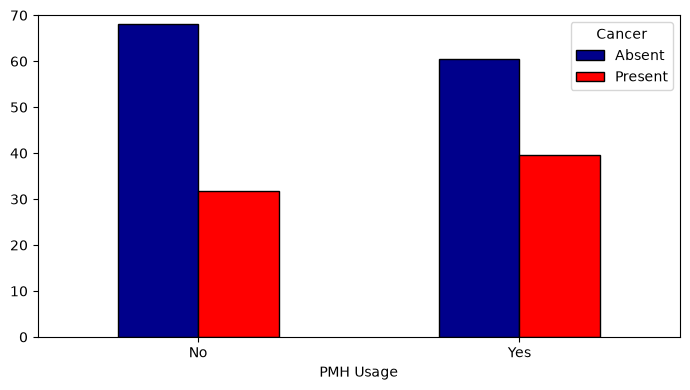

In [ ]:
proptab2 = pd.crosstab(pmh_use, cancer, normalize="index") * 100   # condition on pmh_use
print(proptab2)
 
proptab2.plot(kind="bar", figsize=(7, 4), color=["darkblue", "red"],
                edgecolor="black")
plt.xlabel("PMH Usage")
plt.title("")
plt.ylim(0, 70)
plt.xticks(rotation=0)
plt.legend(title="Cancer")
plt.tight_layout()
plt.show()

### Stacked Bar Plots

To plot a stacked bar plot, it is exactly the same as clustered but include a `"stacked=True"` in your code for plot.

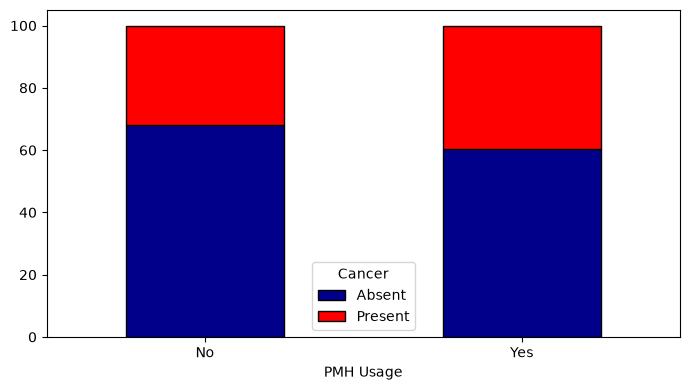

In [ ]:
proptab2.plot(kind="bar", stacked=True, figsize=(7, 4), color=["darkblue", "red"],
                edgecolor="black")
plt.xlabel("PMH Usage")
plt.title("")
plt.xticks(rotation=0)
plt.legend(title="Cancer")
plt.tight_layout()
plt.show()

### Boxplots comparing 2 populations

We decide which variable we want to plot in our $y$-axis, let's say the age at menopause. We then have to break our data up into groups for the $x$-axis. In this case, we want to break it up to absent and present cancer statuses. We will also drop the missing values for each group.

In [ ]:
groups = [bc["agemenop"][cancer == cat] for cat in ["Absent", "Present"]]
print(groups)
#groups is a list of two pandas Series, one for Absent, one for Present

#equivalent statement to what is being done above
groups = [
    bc["agemenop"][cancer == "Absent"],   # a Series of ages where cancer == "Absent"
    bc["agemenop"][cancer == "Present"]  # a Series of ages where cancer == "Present"
]

[4       53
5       41
6       45
7       45
8       51
        ..
1195    49
1196    55
1197    42
1198    38
1199    52
Name: agemenop, Length: 803, dtype: int64, 0       45
1       39
2       36
3       53
14      32
        ..
1180    54
1186    45
1188    27
1191    55
1194    53
Name: agemenop, Length: 397, dtype: int64]


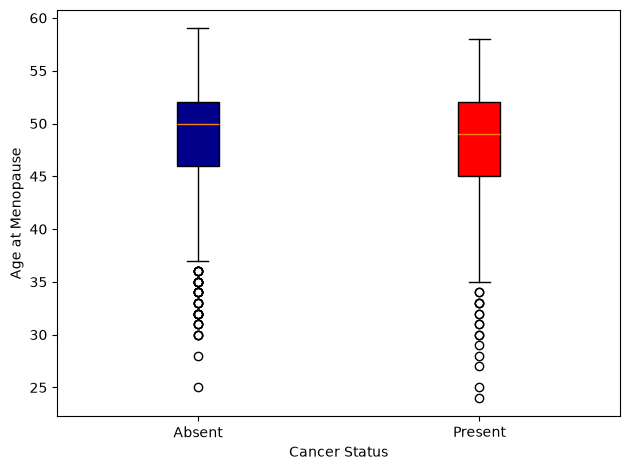

In [ ]:
plt.figure()
bp = plt.boxplot(groups, tick_labels=["Absent", "Present"], patch_artist=True) #patch_artist is to add colour
bp["boxes"][0].set_facecolor("darkblue") # Absent
bp["boxes"][1].set_facecolor("red") # Present
plt.ylabel("Age at Menopause")
plt.xlabel("Cancer Status")
plt.tight_layout()
plt.show()

### Outliers

We can obtain outliers from each group by extracting them separately from the boxplot using `"fliers"`.

In [ ]:
absent_outliers = bp["fliers"][0].get_data()[1] # outliers for Absent
present_outliers = bp["fliers"][1].get_data()[1] # outliers for Present

print(len(absent_outliers), "outliers in Absent group:", absent_outliers)
print(len(present_outliers), "outliers in Present group:", present_outliers)

41 outliers in Absent group: [32 25 32 35 32 36 36 35 32 36 30 33 31 34 33 31 35 34 34 35 36 30 34 33
 34 36 35 36 32 31 34 34 33 35 32 28 35 33 30 31 32]
16 outliers in Present group: [32 24 30 31 31 34 33 33 29 28 32 30 25 34 33 27]


### Boxplots with many categories

The HDB dataset has 7 different flat types. When plotting the resale price by flat type, we will have 7 different boxes.

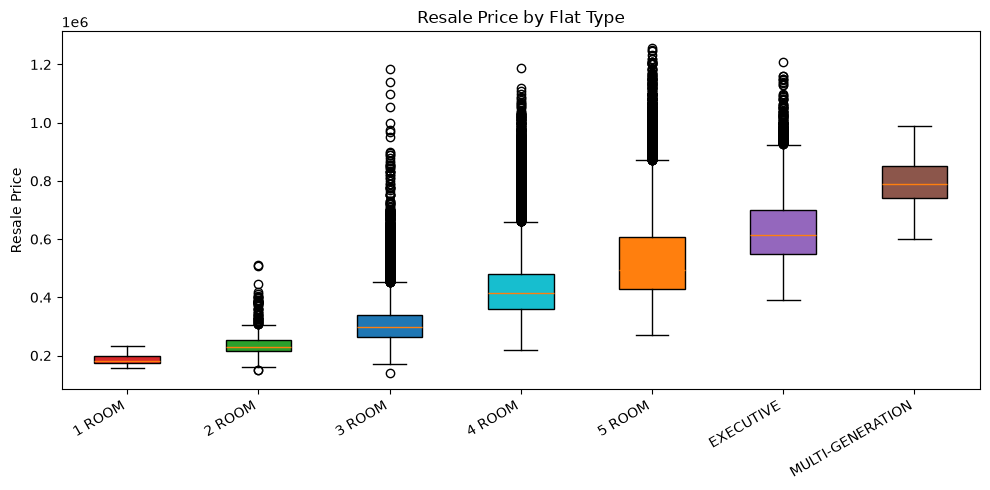

In [ ]:
hdb = pd.read_csv("../data/hdb_2017_now.csv")
 
flat_types = sorted(hdb["flat_type"].unique())
colors = ["tab:red", "tab:green", "tab:blue", "tab:cyan",
          "tab:orange", "tab:purple", "tab:brown"]
 
groups_hdb = [hdb["resale_price"][hdb["flat_type"] == ft].dropna() for ft in flat_types]
 
plt.figure(figsize=(10, 5))
bp = plt.boxplot(groups_hdb, tick_labels=flat_types, patch_artist=True)
for box, color in zip(bp["boxes"], colors):
    box.set_facecolor(color)
plt.xticks(rotation=30, ha="right")
plt.ylabel("Resale Price")
plt.title("Resale Price by Flat Type")
plt.tight_layout()
plt.show()

In such datasets, if you wish to plot the histogram for only one flat type, you will need to filter it out first.

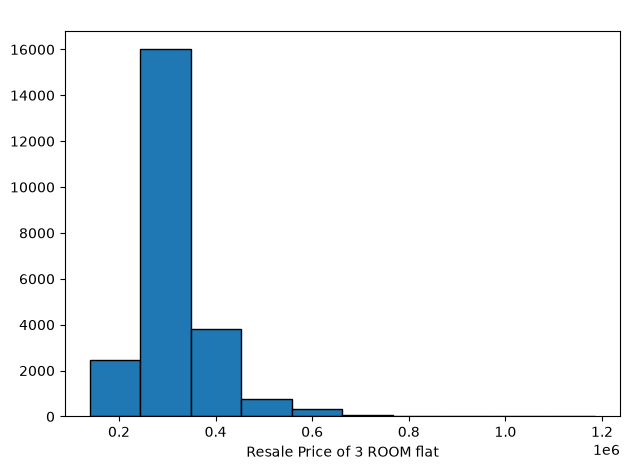

In [ ]:
three_room = hdb["resale_price"][hdb["flat_type"] == "3 ROOM"]
 
plt.figure()
plt.hist(three_room, color="tab:blue", edgecolor="black")
plt.title(" ")
plt.xlabel("Resale Price of 3 ROOM flat")
plt.tight_layout()
plt.show()

### Scatterplots

To plot a scatterplot, we will need to choose our 2 quantitative variables and determine which is $x$ and which is $y$. The first input in the scatter function will be $x$, followed by $y$. The `alpha` parameter is to set the transparency of your points with 0 being fully transparent to 1 being fully opaque. This can be useful to adjust when you have many overlapping points. The `s` parameter is to set the size of your points with a smaller value being smaller dots. This can be useful to adjust for large datasets to reduce clutter.

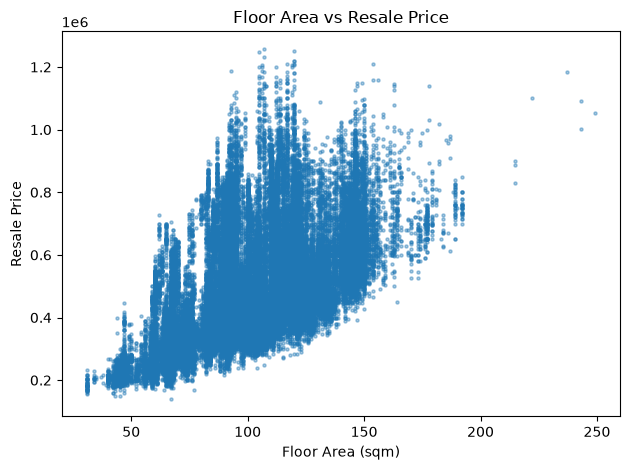

In [ ]:
plt.figure()
plt.scatter(hdb["floor_area_sqm"], hdb["resale_price"], color="tab:blue", alpha=0.4, s=5)
plt.xlabel("Floor Area (sqm)")
plt.ylabel("Resale Price")
plt.title("Floor Area vs Resale Price")
plt.tight_layout()
plt.show()

### Correlation

You can use `pandas` or `numpy` to calculate correlation. The `pandas` version will give us a single value if used in the form of `Series.corr()`, but will give us a correlation matrix of every possible pair if used with `DataFrame` that is numeric-only. The `numpy` version always gives us a correlation matrix and can only be used with 2 variables at a time.

In [ ]:
corr = hdb["floor_area_sqm"].corr(hdb["resale_price"])
print("Correlation using pandas:")
print(corr)
print(round(corr, 4)) #changes actual value
print(f"{corr:.4f}") #formats the display only
print()

corr2 = np.corrcoef(hdb["floor_area_sqm"], hdb["resale_price"])
print("Correlation Matrix")
print(corr2)
print("Correlation using numpy:")
print(corr2[0,1])
print(np.round(corr2[0,1], 4))
print()

corr3 = hdb[["floor_area_sqm", "resale_price", "lease_commence_date"]].corr()
print("Correlation Matrix of every pairing")
print(corr3)

Correlation using pandas:
0.626538211526382
0.6265
0.6265

Correlation Matrix
[[1.         0.62653821]
 [0.62653821 1.        ]]
Correlation using numpy:
0.626538211526382
0.6265

Correlation Matrix of every pairing
                     floor_area_sqm  resale_price  lease_commence_date
floor_area_sqm             1.000000      0.626538             0.164577
resale_price               0.626538      1.000000             0.339948
lease_commence_date        0.164577      0.339948             1.000000
